In [141]:
#Loading the Dataset
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Sales_dataset_for_advanced_task.csv")
print(df.head(5))

  Order_ID   Product     Category  Quantity     Price       City        Date
0  ORD1001  Backpack  Accessories         1   1629.00  Hyderabad  2026-03-04
1  ORD1002  Keyboard  Electronics         2   1570.94      Surat  2026-01-23
2  ORD1003      Book        Books         4    407.86     Mumbai  2026-02-25
3  ORD1004  Keyboard  Electronics         5   1530.61      Surat  2026-02-20
4  ORD1005    Tablet  Electronics         5  27549.31     Jaipur  2026-05-31


In [142]:
#Generating basic details of dataset 
print("Shape of Dataset:\n",df.shape)
print("Statistical Summary:\n",df.describe())

Shape of Dataset:
 (1000, 7)
Statistical Summary:
           Quantity         Price
count  1000.000000   1000.000000
mean      3.035000   8940.486210
std       1.402049  14229.456287
min       1.000000    407.430000
25%       2.000000   1738.235000
50%       3.000000   2962.040000
75%       4.000000   6263.752500
max       5.000000  60347.510000


In [143]:
#Checking Missing Value and Duplicate Entries
print("Checking Missing Value: \n",df.isnull().sum())
print("Checking Duplicate Entries: \n",df.duplicated().sum())

Checking Missing Value: 
 Order_ID    0
Product     0
Category    0
Quantity    0
Price       0
City        0
Date        0
dtype: int64
Checking Duplicate Entries: 
 0


In [144]:
# Adding new features in the Dataset
df["Date"] = pd.to_datetime(df["Date"])
df["Total Sales"] = df["Quantity"] * df["Price"]

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
print(df)

    Order_ID     Product     Category  Quantity     Price       City  \
0    ORD1001    Backpack  Accessories         1   1629.00  Hyderabad   
1    ORD1002    Keyboard  Electronics         2   1570.94      Surat   
2    ORD1003        Book        Books         4    407.86     Mumbai   
3    ORD1004    Keyboard  Electronics         5   1530.61      Surat   
4    ORD1005      Tablet  Electronics         5  27549.31     Jaipur   
..       ...         ...          ...       ...       ...        ...   
995  ORD1996       Watch  Accessories         5   4711.82  Ahmedabad   
996  ORD1997     T-Shirt      Fashion         5    861.96      Surat   
997  ORD1998    Backpack  Accessories         2   1751.69  Bangalore   
998  ORD1999      Tablet  Electronics         3  25949.74      Surat   
999  ORD2000  Smartphone  Electronics         4  17509.92  Ahmedabad   

          Date  Total Sales  Day  Month  Year  
0   2026-03-04      1629.00    4      3  2026  
1   2026-01-23      3141.88   23      1

In [145]:
#Product Category Analysis

# 1. Total Revenue by each Category
category_revenue = df.groupby("Category")["Price"].sum().sort_values(ascending=False)

# 2. Total Quantity by each Category
category_quantity = df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

# 3. Total Orders by each Category
category_orders = df.groupby("Category")["Order_ID"].count().sort_values(ascending=False)

product_Category_Analysis = pd.DataFrame({
    "Total Revenue" : category_revenue,
    "Total Quantity" : category_quantity,
    "Toatal Orders" : category_orders
})
print("Category Summary: \n", product_Category_Analysis)

Category Summary: 
                  Total Revenue  Total Quantity  Toatal Orders
Category                                                     
Accessories          541052.47             482            161
Books                 29889.04             199             66
Electronics         6936409.77            1017            328
Fashion              388651.39             679            226
Home Appliances     1044483.54             658            219


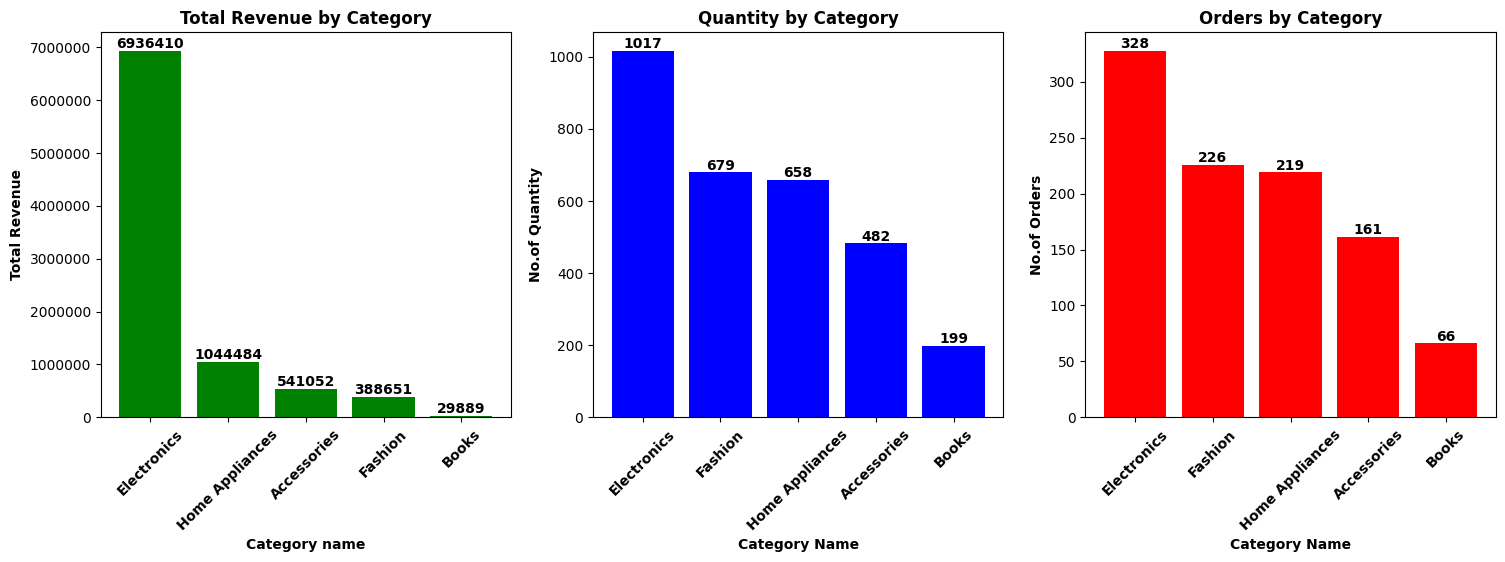

In [146]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
# Revenue by Category
bars = axes[0].bar(category_revenue.index,category_revenue.values,color="Green")
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2,height,f'{height:.0f}',ha="center",va="bottom",fontweight="bold")
axes[0].set_xlabel("Category name",fontweight="bold")
axes[0].set_ylabel("Total Revenue",fontweight="bold")
axes[0].set_title("Total Revenue by Category",fontweight="bold")
for label in axes[0].get_xticklabels():
    label.set_fontweight('bold')
axes[0].ticklabel_format(style="plain",axis="y")
axes[0].tick_params(axis='x', rotation=45)

# Quantity by Category
bar1 = axes[1].bar(category_quantity.index,category_quantity.values,color="blue")
for bar in bar1:
    height = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2,height,f'{height:.0f}',ha="center",va="bottom",fontweight="bold")
axes[1].set_title("Quantity by Category",fontweight="bold")
axes[1].set_xlabel("Category Name",fontweight="bold")
axes[1].set_ylabel("No.of Quantity",fontweight="bold")
for label in axes[1].get_xticklabels():
    label.set_fontweight('bold')
axes[1].ticklabel_format(style="plain",axis="y")
axes[1].tick_params(axis="x",rotation=45)

# Orders by Category
bar2 = axes[2].bar(category_orders.index,category_orders.values,color="red")
for bar in bar2:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2,height,f'{height:.0f}',ha="center",va="bottom",fontweight="bold")
axes[2].set_title("Orders by Category",fontweight="bold")
axes[2].set_xlabel("Category Name",fontweight="bold")
axes[2].set_ylabel("No.of Orders",fontweight="bold")
for label in axes[2].get_xticklabels():
    label.set_fontweight('bold')
axes[2].ticklabel_format(style="plain",axis="y")
axes[2].tick_params(axis="x",rotation=45)
plt.show()

In [148]:
# City-wise Analysis

# 1. Revenue by city
city_revenue = df.groupby("City")["Price"].sum().sort_values(ascending=False)
# 2. Orders by city
city_orders = df.groupby("City")["Order_ID"].count().sort_values(ascending=False)

# 3. Average orders value by city
city_average = df.groupby("City")["Price"].mean().sort_values(ascending=False)

city_summary = pd.DataFrame({
    "Total Revenue" : city_revenue,
    "Total Orders" : city_orders,
    "Average orders value" : city_average
})
print(city_summary)

           Total Revenue  Total Orders  Average orders value
City                                                        
Ahmedabad      724875.98            99           7321.979596
Bangalore      936385.12            88          10640.740000
Chennai        748515.65            98           7637.914796
Delhi          924742.93            94           9837.690745
Hyderabad      662981.52            96           6906.057500
Jaipur        1148632.38           105          10939.356000
Kolkata        874723.25            87          10054.290230
Mumbai        1010348.30           126           8018.637302
Pune          1081316.69           102          10601.144020
Surat          827964.39           105           7885.375143


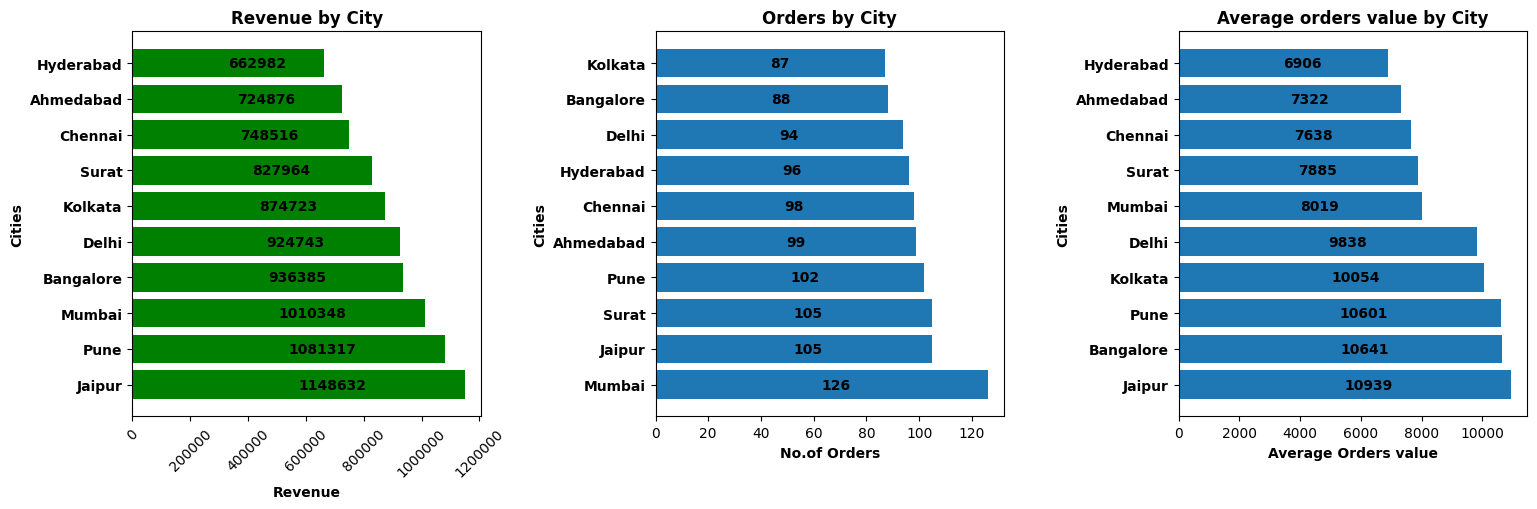

In [9]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
# revenue by city
plt.subplots_adjust(wspace=0.5)
bar1 = axes[0].barh(city_revenue.index,city_revenue.values,color="green")
for bar in bar1:
    width = bar.get_width()
    axes[0].text(width/2,bar.get_y() + bar.get_height()/2,f'{width:.0f}',ha="left",va="center",fontweight="bold")
axes[0].set_title("Revenue by City",fontweight="bold")
axes[0].set_xlabel("Revenue",fontweight="bold")
axes[0].set_ylabel("Cities",fontweight="bold")
axes[0].ticklabel_format(style="plain",axis="x")
axes[0].tick_params(axis="x",rotation=45)
for label in axes[0].get_yticklabels():
    label.set_fontweight("bold")

# orders by city
bar2 = axes[1].barh(city_orders.index,city_orders.values)
for bar in bar2:
    width = bar.get_width()
    axes[1].text(width/2,bar.get_y() + bar.get_height()/2,f'{width:.0f}',ha="left",va="center",fontweight="bold")
axes[1].set_title("Orders by City",fontweight="bold")
axes[1].set_xlabel("No.of Orders",fontweight="bold")
axes[1].set_ylabel("Cities",fontweight="bold")
for label in axes[1].get_yticklabels():
    label.set_fontweight("bold")

# Average orders value by city
bar3 = axes[2].barh(city_average.index,city_average.values)
for bar in bar3:
    width = bar.get_width()
    axes[2].text(width/2,bar.get_y() + bar.get_height()/2,f'{width:.0f}',ha="left",va="center",fontweight="bold")
axes[2].set_title("Average orders value by City",fontweight="bold")
axes[2].set_xlabel("Average Orders value",fontweight="bold")
axes[2].set_ylabel("Cities",fontweight="bold")
for label in axes[2].get_yticklabels():
    label.set_fontweight("bold")
plt.show()

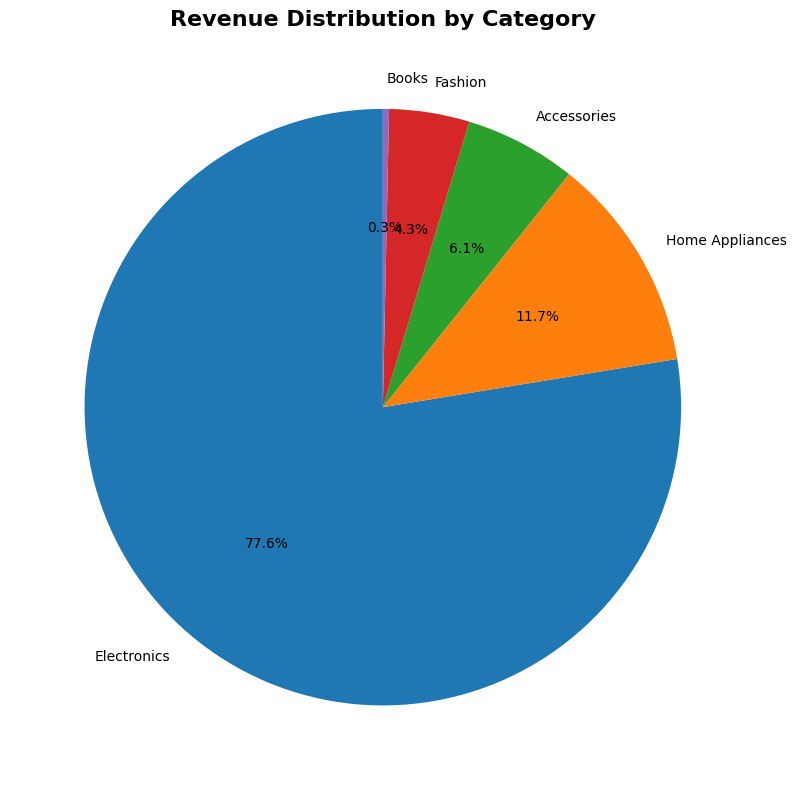

In [10]:
# pie chart for revenue distrubution by category
plt.figure(figsize=(10, 8))
plt.pie(category_revenue.values,labels=category_revenue.index, autopct='%1.1f%%',startangle=90)
plt.title('Revenue Distribution by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Monthly Sales Trend Analysis
# 1. Monthly Sales
monthly_sales = df.groupby("Month")["Price"].sum().reindex()

# 2. Monthly orders
monthly_orders = df.groupby("Month")["Order_ID"].count().reindex()

# 3. Monthly Quantity
monthly_quantity = df.groupby("Month")["Quantity"].sum().reindex()

# Monthly Summary
print("Monthly Summary")
monthly_summary = pd.DataFrame({
    "Monthly Sales" : monthly_sales,
    "Monthly Orders" : monthly_orders,
    "Monthly quantity" : monthly_quantity
})

print(monthly_summary)

Monthly Summary
       Monthly Sales  Monthly Orders  Monthly quantity
Month                                                 
1         1811770.08             170               521
2         1332532.78             151               462
3         1490245.28             181               532
4         1561770.94             164               511
5         1692070.00             184               522
6         1052097.13             150               487


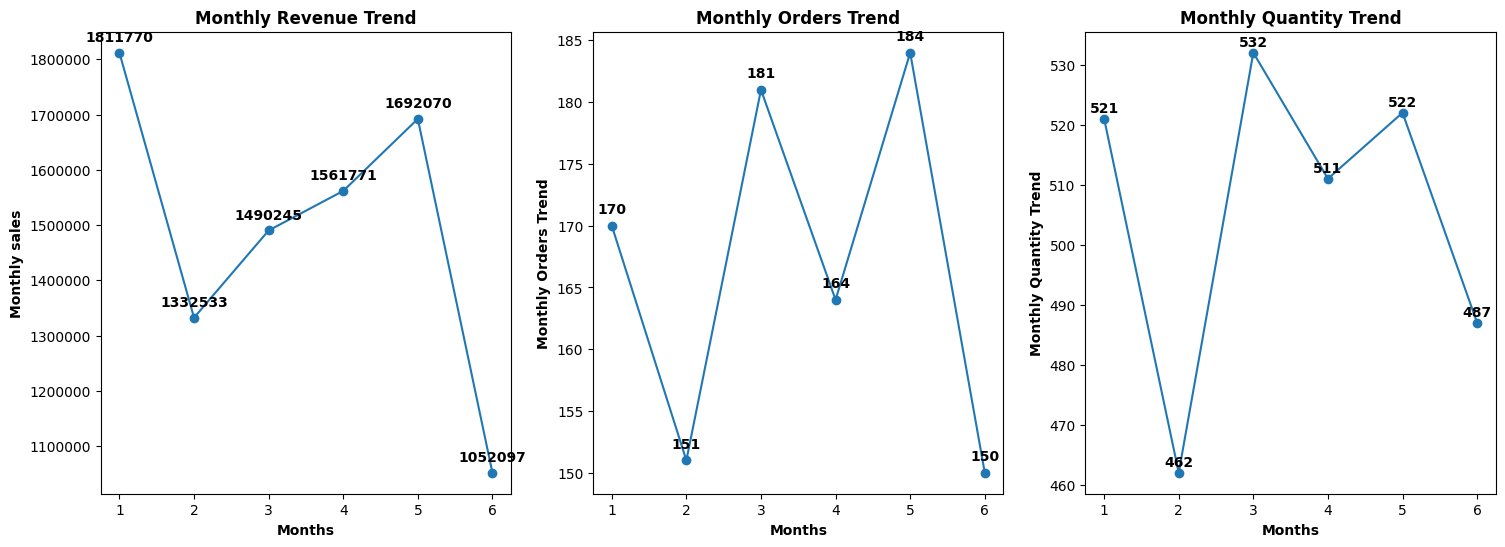

In [35]:
# Scatter plots for monthly analysis

fig, axes = plt.subplots(1,3,figsize=(18,6))
# 1. Monthly Revenue trend
axes[0].plot(monthly_sales.index,monthly_sales.values,marker="o")
axes[0].set_title("Monthly Revenue Trend",fontweight="bold")
axes[0].set_xlabel("Months",fontweight="bold")
axes[0].set_ylabel("Monthly sales",fontweight="bold")
axes[0].ticklabel_format(style="plain",axis="y")
for i,v in enumerate(monthly_sales.values):
    axes[0].text(i+1,v+20000,f'{v:.0f}',ha="center",fontweight="bold")

# Monthly Orders Trend
axes[1].plot(monthly_orders.index,monthly_orders.values,marker="o")
axes[1].set_title("Monthly Orders Trend",fontweight="bold")
axes[1].set_xlabel("Months",fontweight="bold")
axes[1].set_ylabel("Monthly Orders Trend",fontweight="bold")
axes[1].ticklabel_format(style="plain",axis="y")
for i,v in enumerate(monthly_orders.values):
    axes[1].text(i+1,v+1,f'{v:.0f}',ha="center",fontweight="bold")

# Monthlu Quantity Trend
axes[2].plot(monthly_quantity.index,monthly_quantity.values, marker="o")
axes[2].set_title("Monthly Quantity Trend",fontweight="bold")
axes[2].set_xlabel("Months",fontweight="bold")
axes[2].set_ylabel("Monthly Quantity Trend",fontweight="bold")
axes[2].ticklabel_format(style="plain",axis="y")
for i,v in enumerate(monthly_quantity.values):
    axes[2].text(i+1,v+1,f'{v:.0f}',ha="center",fontweight="bold")
plt.show()

In [87]:
# Product Analysis

# 1. Top product by Revenue
top_product_revenue = df.groupby("Product")["Price"].sum().sort_values(ascending=False).head(10)

# 2. Top product by Quantity
top_product_Quantity = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

# 3. Average Price by Product
average_price = df.groupby("Product")["Price"].mean().round(0).sort_values(ascending=False)

print("Top product by Revenue:")
print(top_product_revenue,"\n")

print("Top product by Quantity:")
print(top_product_Quantity)

Top product by Revenue:
Product
Laptop          3590468.75
Tablet          1901307.63
Smartphone      1214061.09
Air Fryer        502356.90
Watch            395040.18
Mixer            272162.04
Coffee Maker     269964.60
Shoes            183068.80
Backpack         146012.29
Jeans            137546.50
Name: Price, dtype: float64 

Top product by Quantity:
Product
T-Shirt      259
Backpack     241
Watch        241
Air Fryer    239
Mixer        226
Keyboard     218
Tablet       215
Jeans        214
Laptop       207
Shoes        206
Name: Quantity, dtype: int64


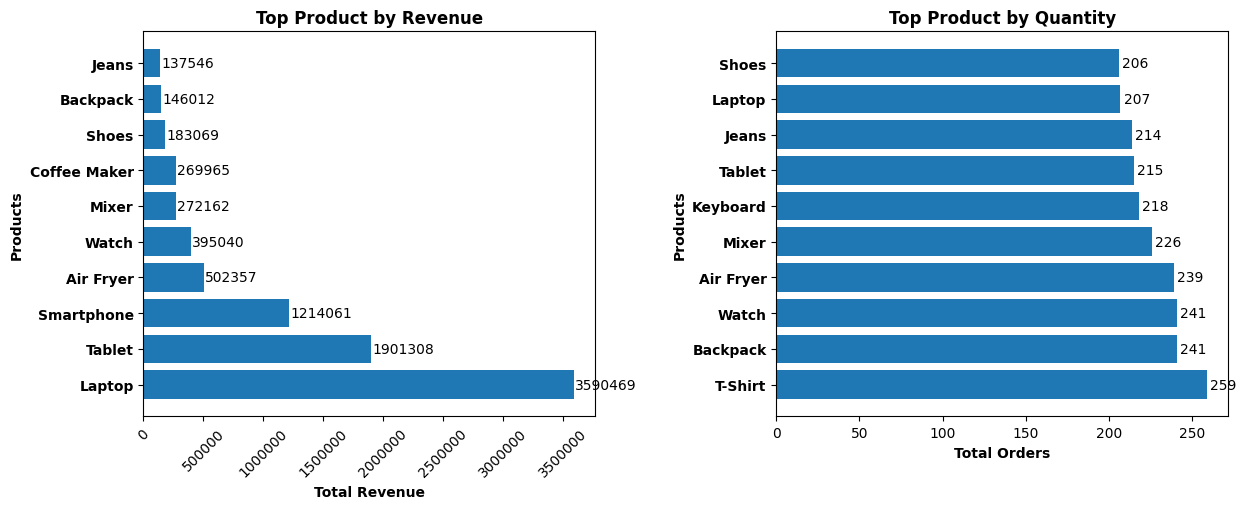

In [103]:
# Visualization of top product

# 1. Top product by revenue
fig, axes = plt.subplots(1,2,figsize=(14,5))
plt.subplots_adjust(wspace=0.4)
bar1 = axes[0].barh(top_product_revenue.index,top_product_revenue.values)
axes[0].set_title("Top Product by Revenue",fontweight="bold")
axes[0].set_xlabel("Total Revenue",fontweight="bold")
axes[0].set_ylabel("Products",fontweight="bold")
for bar in bar1:
    width = bar.get_width()
    axes[0].text(width+10000,bar.get_y() + bar.get_height()/2,f"{width:.0f}",va="center")
axes[0].ticklabel_format(style="plain",axis="x")
axes[0].tick_params(axis="x",rotation=45)
for label in axes[0].get_yticklabels():
    label.set_fontweight("bold")

# 2. Top Product by Quantity
bar2 = axes[1].barh(top_product_Quantity.index,top_product_Quantity.values)
axes[1].set_title("Top Product by Quantity",fontweight="bold")
axes[1].set_xlabel("Total Orders",fontweight="bold")
axes[1].set_ylabel("Products",fontweight="bold")
for bar in bar2:
    width = bar.get_width()
    axes[1].text(width+2,bar.get_y() + bar.get_height()/2,f"{width:.0f}",va="center")
for label in axes[1].get_yticklabels():
    label.set_fontweight("bold")

# 3.
plt.show()

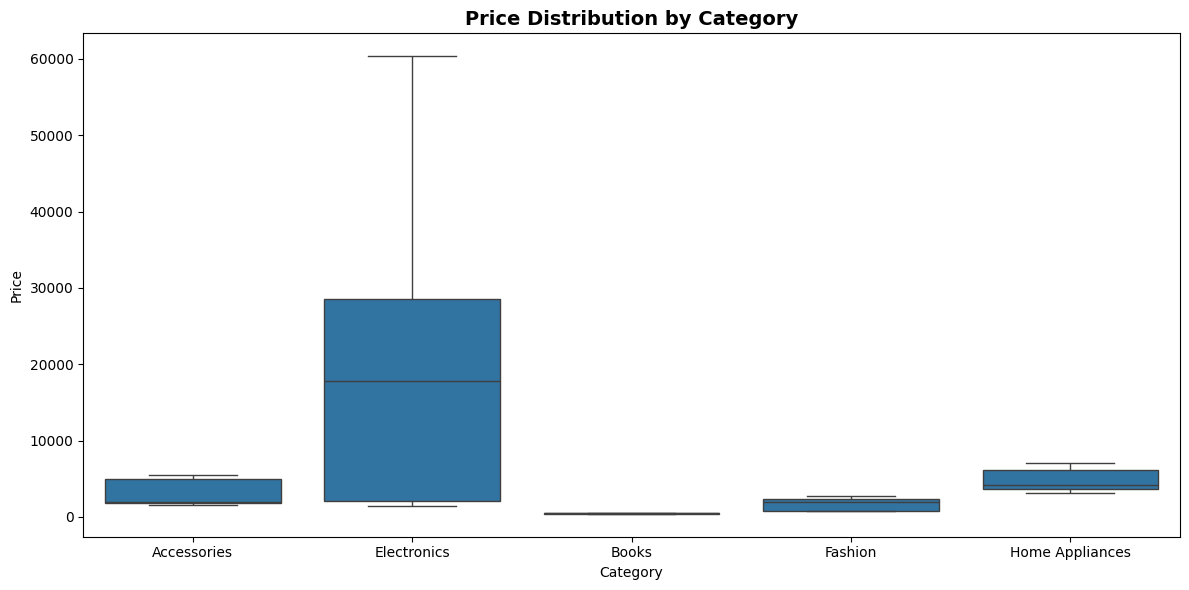

In [111]:
# Price Distribution Analysis
import seaborn as sns
plt.figure(figsize=(12,6))
sns.boxplot(x="Category",y="Price",data=df)
plt.title('Price Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Price')
plt.tight_layout()
plt.show()